# SMARTPHONE TO DERMATOSCOPE

Smartphones and dermatoscopes can both take pictures of skin, but they’re not playing in the same league. Here’s the breakdown in a chill, straightforward way:

## 📱 Smartphone

General-purpose camera – good for everyday photos, not optimized for skin structures.
Lighting – uses regular LED flash; not polarized, not consistent.
Magnification – digital zoom (basically cropping the image), so fine details get lost.
Image quality – depends on the model, but still limited for medical diagnosis.
Use case – casual tracking of a mole, sharing a photo with your dermatologist, teledermatology screening.

## 🔍 Dermatoscope

Specialized medical tool designed specifically for skin lesion examination.
Optics – true optical magnification (usually 10×) with high precision.
Lighting – polarized or non-polarized LED rings to remove reflection and reveal subsurface structures.
Detail level – shows pigment networks, vascular patterns, and other micro-features you’d never see with a phone alone.
Image consistency – standardised images that dermatologists trust for diagnosis and monitoring changes over time.
Use case – professional diagnosis, melanoma detection, clinical documentation.

## 📱➕🔍 Smartphone + Dermatoscope Adapters

There are dermatoscope lenses designed to clip onto a phone. These combine the convenience of a smartphone with dermatoscope-level lighting and magnification. Super handy for teledermatology or research.

# HAM10000

Here are the key facts and considerations about the HAM10000 dataset.

## 🧐 What it is

- HAM10000 stands for “Human Against Machine with 10000 training images”. 
- It is a large collection of 10 015 dermatoscopic images of pigmented skin lesions, collected from multiple sources (Vienna, Austria and Queensland, Australia) over ~20 years. 
-It covers a variety of lesion types (not just melanomas and nevi) — 7 diagnostic categories including melanocytic nevi (NV), melanoma (MEL), basal cell carcinoma (BCC), actinic keratoses / intraepithelial carcinoma (AKIEC), benign keratosis-like lesions (BKL), dermatofibroma (DF), vascular lesions (VASC). 
- More than 50% of the lesions have histopathologic confirmation; the remainder follow-up or expert consensus. 
- It is publicly available via the International Skin Imaging Collaboration (ISIC) archive under a research licence. 

## 🎯 Why it's useful

- Because of its size, diversity (multiple populations, modalities) and variety of diagnostic classes, HAM10000 is a benchmark dataset for machine learning in skin lesion classification/detection. 
- Many research papers have used HAM10000 for training and evaluation of CNNs, transfer learning, segmentation tasks, etc. 

## ⚠️ Limitations and things to watch

- Although large, HAM10000 still has class imbalance (some lesion types are far more common than others) and bias in skin types and acquisition settings. For example: a recent study identified racial/skin tone bias in dermoscopy repositories (including HAM10000) because many images come from lighter skin types. 
Wiley Online Library
- Because images were collected under dermoscopic conditions, they may not represent smartphone/clinical camera images; so if your target application is smartphone images, you may face domain mismatch.
- Metadata: although there is metadata (age, sex, site, diagnosis_confirm_type, etc.), some details of imaging conditions, zoom, exact dermoscope device, illumination may be missing or heterogeneous. E.g., “Zoom level can immensely affect the analysis… Since we have no information about it in the data …” 
- As with any dataset, the ground truth is not perfect (in-vivo confocal, follow-up or expert consensus replaces biopsy sometimes) so one must be cautious when reporting performance.

## 🖼 Image Characteristics

- All images are dermoscopic, not smartphone.
- Size: roughly 450×600 px, JPEG.
- Mixed acquisition devices (several dermatoscopes, polarized / non-polarized).
- Colors are fairly consistent compared to smartphone pics but still show some variability (lighting, zoom, immersion fluid).

## 📊 HAM10000 — Class Distribution with Risk Levels

| Label | Meaning                                                             | Count | Risk Level |
|-------|----------------------------------------------------------------------|-------|------------|
| **NV**   | Melanocytic nevi                                                    | 6 705 | **Benign** |
| **MEL**  | Melanoma                                                            | 1 113 | **High-risk** |
| **BKL**  | Benign keratosis-like lesions (seborrheic keratosis, solar lentigo) | 1 099 | **Benign** |
| **AKIEC**| Actinic keratoses / intraepithelial carcinoma (Bowen’s disease)     | 327   | **Risky** (premalignant) |
| **BCC**  | Basal cell carcinoma                                                | 514   | **High-risk** (malignant but low metastatic risk) |
| **DF**   | Dermatofibroma                                                      | 115   | **Benign** |
| **VASC** | Vascular lesions (angiomas, hematomas, angiokeratomas)              | 142   | **Benign** |


The dataset is highly unbalanced.

## 📸 Can we transform a classic image into a dermatoscope image ?

It is possible to simulate a “dermoscopic” effect, but be careful:

This is only a visual effect. It does not provide any real dermoscopic diagnostic information and should not be used to make medical decisions under any circumstances.

## 🧰 How to do this, with what tools

We can use OpenCV for Python library (cv2)
https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html

It’s one of the most widely used libraries for:
- reading and writing images
- image processing (blur, contrast, color conversions, filters…)
- video processing
- drawing shapes, applying masks
- computer vision tasks (object detection, feature extraction, etc.)

How install OpenCV : pip install opencv-python

In [1]:
!pip install opencv-python

## ✨ We can use CLAHE functions.

**CLAHE** stands for **Contrast Limited Adaptive Histogram Equalization**.  
It is an image-processing technique used to **enhance local contrast** while avoiding the excessive amplification of noise.

---

### 🔍 Why use CLAHE?

CLAHE makes small structures easier to see, especially in medical or low-contrast images.  
It is useful for highlighting:

- pigment networks  
- lesion borders  
- subtle textures  
- color variations  

This makes it particularly relevant in dermoscopy or any task requiring fine detail visibility.

---

### 🧠 How CLAHE works

1. **Adaptive:**  
   The image is divided into small tiles (e.g., 8×8).  
   Each tile is enhanced independently.

2. **Histogram Equalization:**  
   Each tile gets its own histogram adjustment, improving local contrast.

3. **Contrast Limited:**  
   CLAHE clips the histogram using a *clip limit* to prevent over-contrasting and noise amplification.  
   This is the "CL" in *Contrast Limited*.

---

### 🛠 CLAHE in OpenCV

```python
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L_eq = clahe.apply(L_channel)


## 🧩 Coding proposal for the image transformation function

### 📉 Graphical view of `smartphone_to_ham_like` pipeline

You can see the transformation steps as a simple processing pipeline:

```mermaid
flowchart LR
    A[📱 Input image<br>(BGR smartphone photo)] --> B[🔲 crop_center_square<br>Center crop to square]
    B --> C[📏 resize_image<br>Resize to out_size × out_size]
    C --> D[✨ apply_clahe_lab<br>Local contrast enhancement (CLAHE in LAB)]
    D --> E[🎯 apply_bilateral_filter<br>Edge-preserving smoothing]
    E --> F[🎨 boost_hsv<br>Increase saturation + brightness (HSV)]
    F --> G[📊 Output HAM-like image]
```

---

#### 🔁 Step-by-step summary

| Step | Function               | Role                                             | Input shape                  | Output shape                 |
|------|------------------------|--------------------------------------------------|------------------------------|------------------------------|
| 1    | `crop_center_square`   | Take the central square from the original image | `(H, W, 3)`                  | `(min(H, W), min(H, W), 3)` |
| 2    | `resize_image`         | Resize to a fixed square size                    | square image                 | `(out_size, out_size, 3)`   |
| 3    | `apply_clahe_lab`      | Improve local contrast in LAB color space        | `(out_size, out_size, 3)`    | same                        |
| 4    | `apply_bilateral_filter` | Smooth noise while preserving edges            | `(out_size, out_size, 3)`    | same                        |
| 5    | `boost_hsv`            | Boost saturation and brightness in HSV          | `(out_size, out_size, 3)`    | same                        |

The function `smartphone_to_ham_like` just chains these steps:

```
Input image
    → crop_center_square
    → resize_image
    → apply_clahe_lab
    → apply_bilateral_filter
    → boost_hsv
    → Output HAM-like image
```


In [14]:
import cv2
import numpy as np


def crop_center_square(img: np.ndarray) -> np.ndarray:
    """
    Crop an image to a centered square based on its shortest side.

    Args:
        img (np.ndarray): Input BGR image.

    Returns:
        np.ndarray: Center-cropped square image.
    """
    height, width = img.shape[:2]
    side = min(height, width)
    y0 = (height - side) // 2
    x0 = (width - side) // 2
    return img[y0:y0 + side, x0:x0 + side].copy()


def resize_image(img: np.ndarray, out_size: int) -> np.ndarray:
    """
    Resize an image to a square of size (out_size × out_size)
    using area interpolation (recommended for downscaling).

    Args:
        img (np.ndarray): Input BGR image.
        out_size (int): Target width/height in pixels.

    Returns:
        np.ndarray: Resized image.
    """
    return cv2.resize(img, (out_size, out_size),
                      interpolation=cv2.INTER_AREA)


def apply_clahe_lab(img: np.ndarray,
                    clip_limit: float = 2.0,
                    tile_grid: tuple = (8, 8)) -> np.ndarray:
    """
    Apply local contrast enhancement using CLAHE on the L channel
    of the LAB color space.

    Args:
        img (np.ndarray): Input BGR image.
        clip_limit (float): Controls max contrast amplification.
        tile_grid (tuple): Size of local regions for equalization.

    Returns:
        np.ndarray: Contrast-enhanced image in BGR.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit,
                            tileGridSize=tile_grid)
    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)


def apply_bilateral_filter(
    img: np.ndarray,
    diameter: int = 9,
    sigma_color: float = 75,
    sigma_space: float = 75
) -> np.ndarray:
    """
    Apply a bilateral filter to reduce noise while preserving edges.

    This filter is different from Gaussian blur:
    - Gaussian blur smooths everything, including edges.
    - Bilateral filter smooths uniform regions (skin, background)
      *but keeps edges sharp* (lesion borders, hair structures).

    Args:
        img (np.ndarray): Input BGR image.
        diameter (int): Pixel neighborhood diameter.
        sigma_color (float): Filter sigma in color space.
        sigma_space (float): Filter sigma in spatial space.

    Returns:
        np.ndarray: Edge-preserving smoothed image.
    """
    return cv2.bilateralFilter(
        img,
        d=diameter,
        sigmaColor=sigma_color,
        sigmaSpace=sigma_space
    )


def boost_hsv(
    img: np.ndarray,
    sat_factor: float = 1.2,
    val_factor: float = 1.05
) -> np.ndarray:
    """
    Increase saturation and brightness in HSV space
    while keeping hue unchanged.

    Args:
        img (np.ndarray): Input BGR image.
        sat_factor (float): Multiplicative factor for saturation.
        val_factor (float): Multiplicative factor for brightness.

    Returns:
        np.ndarray: Color-enhanced image in BGR.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h_channel, s_channel, v_channel = cv2.split(hsv)

    s_channel *= sat_factor
    v_channel *= val_factor

    s_channel = np.clip(s_channel, 0, 255)
    v_channel = np.clip(v_channel, 0, 255)

    hsv_boosted = cv2.merge(
        (h_channel, s_channel, v_channel)
    ).astype(np.uint8)

    return cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)

def smartphone_to_ham_like(img: np.ndarray,
                           out_size: int = 512) -> np.ndarray:
    """
    Convert a smartphone image into a visually HAM10000-like version.
    This includes:
    - square cropping
    - resizing
    - contrast enhancement (CLAHE)
    - bilateral smoothing
    - HSV-based color/brightness boost

    Args:
        img (np.ndarray): Input BGR image.
        out_size (int): Output image size in pixels.

    Returns:
        np.ndarray: Processed BGR image.
    """
    img_cropped = crop_center_square(img)
    img_resized = resize_image(img_cropped, out_size)
    img_contrast = apply_clahe_lab(img_resized)
    img_smooth = apply_bilateral_filter(img_contrast)
    img_boosted = boost_hsv(img_smooth)
    return img_boosted


### 📚 Lexicon of OpenCV Functions Used

- **cv2.resize()**  
  Resizes the image to a fixed output size (out_size × out_size).

- **cv2.cvtColor()**  
  Converts between color spaces (BGR ↔ LAB ↔ HSV).  
  Used for CLAHE (LAB) and color boosting (HSV).

- **cv2.split()**  
  Splits the image into separate channels (L/A/B or H/S/V).

- **cv2.merge()**  
  Merges multiple channels back into one image.

- **cv2.createCLAHE()**  
  Creates a CLAHE algorithm for adaptive contrast enhancement.

- **clahe.apply()**  
  Applies CLAHE to the L (luminance) channel.

- **cv2.bilateralFilter()**  
  Smooths the image while preserving edges, giving a cleaner, more “optical” look.


## 🧩 Explanation of the function call `smartphone_to_ham_like(img, out_size=512)`

### Function signature
smartphone_to_ham_like(img: np.ndarray, out_size: int = 512) -> np.ndarray

## 1️⃣ Parameters

### 1. `img`
- Type: np.ndarray
- Description:
  The input image to be transformed. It must be a NumPy array in OpenCV BGR format.
- Shape: (H, W, 3)
- Purpose:
  Represents the smartphone photo you want to convert into a HAM10000-like dermoscopic image.

### 2. `out_size`
- Type: int
- Default: 512
- Description:
  Defines the final size of the output image.
  The output will be out_size × out_size pixels.
- Why it matters:
  Ensures compatibility with deep-learning input sizes (e.g. EfficientNet-B3 → 300).

## 2️⃣ Returned value
- Type: np.ndarray
- Shape: (out_size, out_size, 3)
- Format: BGR
- Meaning:
  The processed image visually adjusted to resemble a HAM10000 dermoscopic image.


## Final test

### 📊 Evaluation Pipeline — Side‑by‑Side Comparison + Analysis

This cell explains the evaluation code used to compare original smartphone images with HAM‑like transformed images.

It processes all PNG files in `data_for_test/`, displays:
- the original image  
- the transformed image  
- a textual analysis (contrast, saturation, smoothing)

---

### 🛠 Pipeline Overview

```mermaid
flowchart LR
    A[📁 Load PNG files<br>from data_for_test/] --> B[📥 cv2.imread<br>Load each image (BGR)]
    B --> C[🔄 smartphone_to_ham_like<br>Apply full preprocessing pipeline]
    C --> D[🧮 describe_changes<br>Compute metrics]
    D --> E[📊 Display results<br>3‑column grid]
```

---

### 🧠 What each block does

#### 🔹 1. Loading images  
```python
img = cv2.imread(path)
```
- Reads a PNG file  
- Returns a NumPy array `(H, W, 3)`  
- Color format: **BGR** (OpenCV default)  
- Stored in `imgs_original`

---

#### 🔹 2. Transformation  
```python
transformed = smartphone_to_ham_like(img, out_size=300)
```
Applies your full pipeline:
- crop → resize → CLAHE → smoothing → HSV boost  
- Output stored in `imgs_transformed`

---

#### 🔹 3. Analysis  
`describe_changes(original, transformed)` computes:

| Metric | How it is computed | Meaning |
|--------|--------------------|---------|
| Size | `shape` | Ensures resize is correct |
| Contrast | `std()` | Higher std → more contrast |
| Saturation | Mean of HSV S channel | Detects color boost |
| Noise/Edges | `Laplacian(...).var()` | Lower variance → more smoothing |

---

#### 🔹 4. Display  
A grid of **three columns × N rows**:

| Original | Transformed | Analysis |
|----------|-------------|----------|

Uses:  
```python
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
```
to convert BGR → RGB for correct visualization.

---

### 📌 Final structure of the display loop

```
for each image:
    col 1 → original
    col 2 → transformed
    col 3 → analysis text
```

---

### 🧾 Summary

This evaluation cell allows you to:
- visually inspect each transformation step  
- verify contrast and saturation enhancements  
- quantify smoothing  
- confirm dimensional consistency  
- ensure pipeline quality before training EfficientNet  


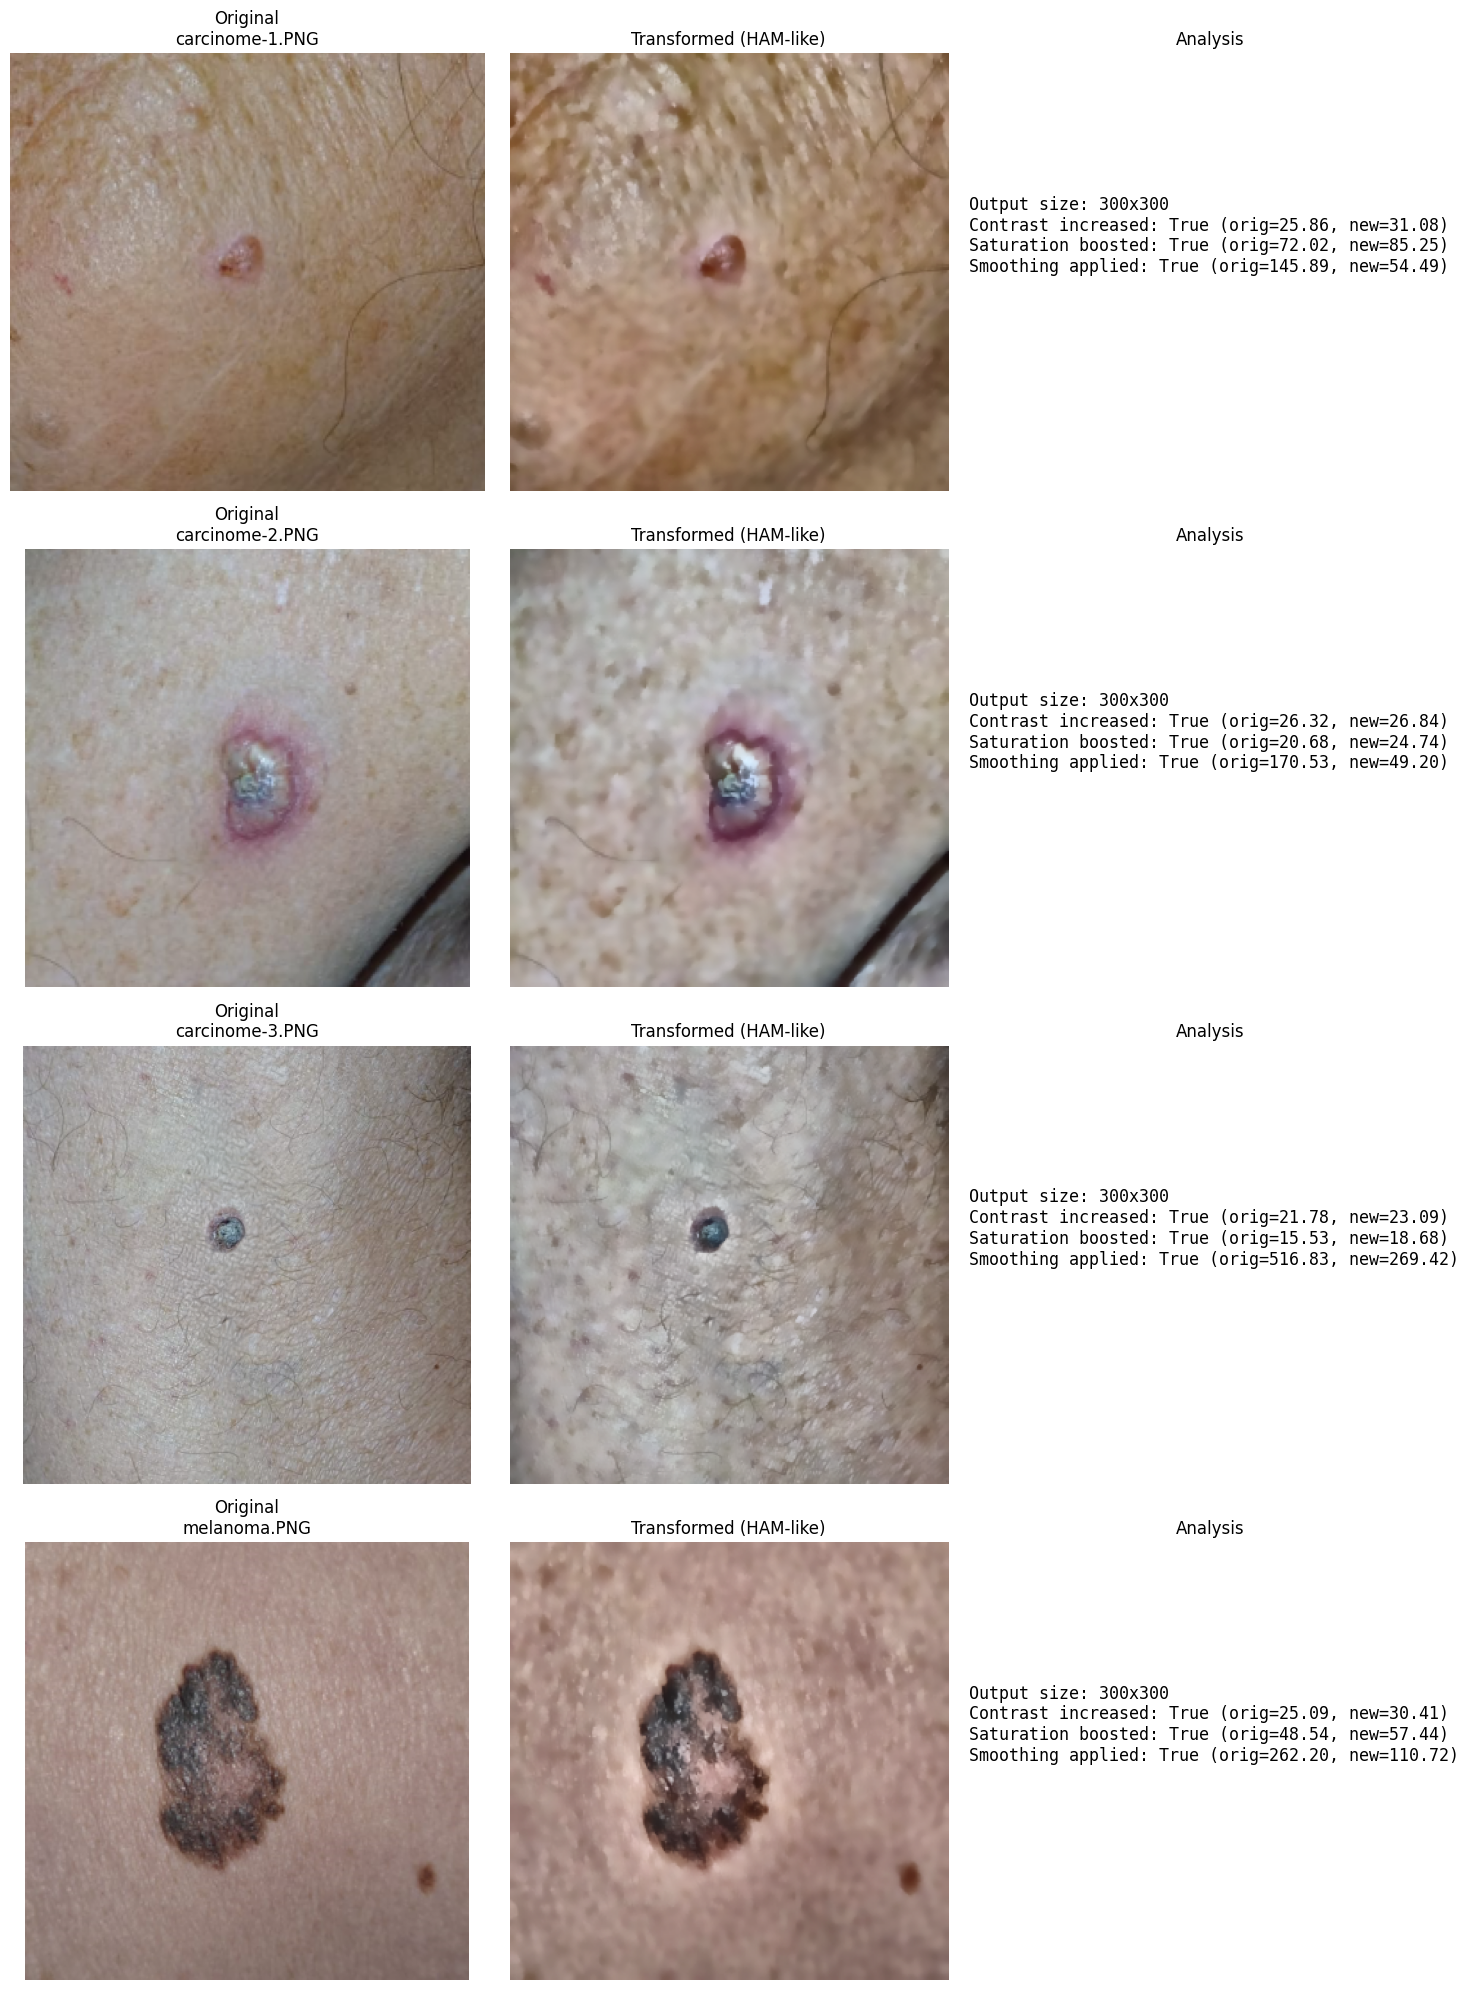

Saved 4 transformed images to 'data_for_test_transformed'


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Helper: textual analysis
# -----------------------------
def describe_changes(original, transformed):
    analysis = []

    # 1. Size change
    analysis.append(f"Output size: {transformed.shape[0]}x{transformed.shape[1]}")

    # 2. Contrast
    orig_contrast = original.std()
    trans_contrast = transformed.std()
    analysis.append(
        f"Contrast increased: {trans_contrast > orig_contrast} "
        f"(orig={orig_contrast:.2f}, new={trans_contrast:.2f})"
    )

    # 3. Color / saturation
    orig_sat = cv2.cvtColor(original, cv2.COLOR_BGR2HSV)[:,:,1].mean()
    trans_sat = cv2.cvtColor(transformed, cv2.COLOR_BGR2HSV)[:,:,1].mean()
    analysis.append(
        f"Saturation boosted: {trans_sat > orig_sat} "
        f"(orig={orig_sat:.2f}, new={trans_sat:.2f})"
    )

    # 4. Smoothing
    orig_noise = cv2.Laplacian(original, cv2.CV_64F).var()
    trans_noise = cv2.Laplacian(transformed, cv2.CV_64F).var()
    analysis.append(
        f"Smoothing applied: {trans_noise < orig_noise} "
        f"(orig={orig_noise:.2f}, new={trans_noise:.2f})"
    )

    return "\n".join(analysis)


# -----------------------------
# Load test images
# -----------------------------
folder = "data_for_test"
image_files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]
image_files = sorted(image_files)  # for reproducibility

imgs_original = []
imgs_transformed = []

for file in image_files:
    img = cv2.imread(os.path.join(folder, file))
    imgs_original.append(img)

    # Apply your transformation
    transformed = smartphone_to_ham_like(img, out_size=300)
    imgs_transformed.append(transformed)


# -----------------------------
# Display results (3 columns)
# -----------------------------

rows = len(imgs_original)
plt.figure(figsize=(16, 5 * rows))

for i in range(rows):

    # Column 1 → original image
    plt.subplot(rows, 3, i*3 + 1)
    plt.imshow(cv2.cvtColor(imgs_original[i], cv2.COLOR_BGR2RGB))
    plt.title(f"Original\n{image_files[i]}")
    plt.axis("off")

    # Column 2 → transformed image
    plt.subplot(rows, 3, i*3 + 2)
    plt.imshow(cv2.cvtColor(imgs_transformed[i], cv2.COLOR_BGR2RGB))
    plt.title("Transformed (HAM-like)")
    plt.axis("off")

    # Column 3 → analysis
    plt.subplot(rows, 3, i*3 + 3)
    plt.text(
        0.0, 0.5,
        describe_changes(imgs_original[i], imgs_transformed[i]),
        fontsize=12,
        family="monospace"
    )
    plt.title("Analysis")
    plt.axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# Save transformed images
# -----------------------------
output_folder = "data_for_test_transformed"
os.makedirs(output_folder, exist_ok=True)

for file, transformed_img in zip(image_files, imgs_transformed):
    out_path = os.path.join(output_folder, f"transformed_{file}")
    cv2.imwrite(out_path, transformed_img)

print(f"Saved {len(imgs_transformed)} transformed images to '{output_folder}'")


## 📚 Explanation of `cv2` calls used in the evaluation code

This section explains all OpenCV (`cv2`) calls used in the image evaluation pipeline (original ➜ transformed ➜ analysis).

---

### 🔹 `cv2.imread(path)`
Loads an image from disk.

- Returns a NumPy array of shape `(H, W, 3)`
- Color format = **BGR** (OpenCV default)
- Used here to load test PNG files from `data_for_test/`.

---

### 🔹 `cv2.cvtColor(original, cv2.COLOR_BGR2HSV)`
### 🔹 `cv2.cvtColor(transformed, cv2.COLOR_BGR2HSV)`
Converts an image from **BGR** to **HSV** color space.

Used in the analysis to extract the **S (saturation)** channel and compute:
- the average saturation of the original image  
- the average saturation of the transformed image  

This allows detection of saturation boost.

---

### 🔹 `cv2.Laplacian(original, cv2.CV_64F)`
### 🔹 `cv2.Laplacian(transformed, cv2.CV_64F)`
Computes the **Laplacian operator**, which measures the amount of high-frequency detail (edges, noise).

Then `.var()` is applied to compute the **variance**:
- High variance → more noise/texture  
- Low variance → the image is smoother  

This is used to quantify the effect of bilateral smoothing.

---

### 🔹 `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`
OpenCV stores images as **BGR**, but Matplotlib displays them as **RGB**.

This conversion ensures correct color display in the output grid.

---

### 🔹 Summary table

| Function | Purpose |
|----------|---------|
| `cv2.imread()` | Load PNG files from disk |
| `cv2.cvtColor(..., BGR2HSV)` | Measure saturation (HSV channel S) |
| `cv2.cvtColor(..., BGR2RGB)` | Display images correctly with Matplotlib |
| `cv2.Laplacian(...).var()` | Estimate noise/texture level for smoothing analysis |
| `cv2.CV_64F` | High-precision depth for Laplacian computation |

---


## 🎨 What is HSV?

**HSV** is a color space that represents colors using three components:

- **H – Hue**
- **S – Saturation**
- **V – Value (Brightness)**

HSV is often used in image processing because it separates **color information** from **brightness**, making it easier to enhance or analyze images.

---

## 🌈 1. Hue (H)
Hue defines the **type of color**.  
In OpenCV, Hue ranges from **0 to 180** (scaled from the usual 0–360° color wheel).

Examples:

| Hue value | Color |
|----------|--------|
| 0 | Red |
| 30 | Yellow |
| 60 | Green |
| 90 | Cyan |
| 120 | Blue |
| 150 | Magenta |
| 180 | Back to Red |

Hue contains **only** the “color family”, not brightness or intensity.

---

## 🎚 2. Saturation (S)
Saturation measures **color intensity**.

- Low S → faded, grayish colors  
- High S → vivid, intense colors  

Range in OpenCV: **0 to 255**

In your transformation pipeline, you increase saturation by **20%** to enhance color richness.

---

## 💡 3. Value (V)
Value represents **brightness** of the pixel.

- Low V → dark  
- High V → bright  

Range in OpenCV: **0 to 255**

Your pipeline increases brightness slightly (+5%) to improve visibility.

---

## 🎯 Why HSV is useful in image enhancement?

Unlike RGB/BGR, HSV cleanly separates:

- **Color (H)**  
- **Intensity (S)**  
- **Brightness (V)**  

This allows you to:

- Boost brightness *without altering color*
- Enhance saturation *without affecting brightness*
- Keep hue unchanged so **skin tone remains natural**

Perfect for medical/digital dermoscopy processing.

---

## 📘 Summary

| Channel | Meaning | Role in your pipeline |
|---------|---------|------------------------|
| **H** | Color type | Kept unchanged to preserve natural skin color |
| **S** | Color intensity | Increased by ×1.2 (stronger colors) |
| **V** | Brightness | Increased by ×1.05 (slightly brighter image) |

---
